# Simple Linear Regression Example: House Price Prediction

This project aims to predict the price of a house based on its area using simple linear regression. The dataset used in this project consists of 1000 houses in Monroe Township, New Jersey, and their respective areas and prices. Here house price is a dependent variable and the area of the house is the independent variable.

The data is stored in a CSV file named `house-prices.csv`.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline

#from sklearn import linear_model

# import warnings
# warnings.filterwarnings('ignore', message='X does not have valid feature names')

In [2]:
file_path = r"D:\sandeep\Introduction to machine learning\Lab\data\house-prices.csv"
df = pd.read_csv(file_path)

In [3]:
print(df.head())

   area      price
0  1567  177067.50
1  3345  511748.20
2  3722  404096.67
3  2783  357916.31
4  2949  362409.54


In [4]:
# Step 3: Extract features and target
X = df["area"].tolist()
y = df["price"].tolist()

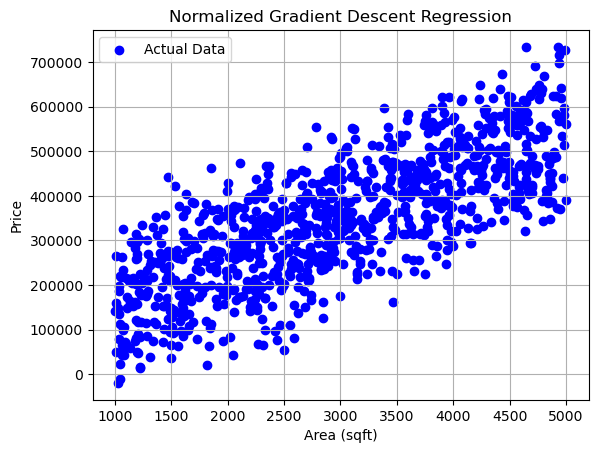

In [5]:
plt.scatter(X, y, color='blue', label='Actual Data')
#plt.plot(X, y_pred, color='red', label='Regression Line')
plt.xlabel("Area (sqft)")
plt.ylabel("Price")
plt.title("Normalized Gradient Descent Regression")
plt.legend()
plt.grid(True)
plt.show()

In [6]:
# Step 4: Define Linear Regression (from scratch)
class LinearRegression:
    def __init__(self):
        self.m = 0
        self.c = 0

    def fit(self, X, y):
        n = len(X)
        x_mean = sum(X) / n
        y_mean = sum(y) / n

        numerator = sum((X[i] - x_mean) * (y[i] - y_mean) for i in range(n))
        denominator = sum((X[i] - x_mean)**2 for i in range(n))

        self.m = numerator / denominator
        self.c = y_mean - self.m * x_mean

    def predict(self, X):
        return [self.m * x + self.c for x in X]


In [7]:
# Step 4: Fit the model
model = LinearRegression()
model.fit(X, y)

In [8]:
# Step 5: Make predictions
predictions = model.predict(X)

In [9]:
# Step 6: Output model parameters
print("Slope (m):", model.m)
print("Intercept (c):", model.c)

Slope (m): 96.59803978824873
Intercept (c): 60953.77652271959


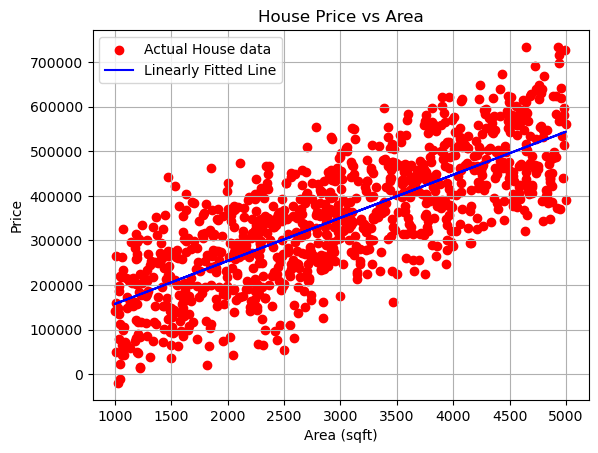

In [10]:
# Step 7: Plot data and regression line
plt.scatter(X, y, color='red', label='Actual House data')
plt.plot(X, predictions, color='blue', label='Linearly Fitted Line')
plt.xlabel('Area (sqft)')
plt.ylabel('Price')
plt.title('House Price vs Area')
plt.legend()
plt.grid(True)
plt.show()

In [42]:
# Step 3: Linear Regression using Gradient Descent (exact update rule)
class LinearRegressionGD:
    def __init__(self, learning_rate=0.00001, max_epochs=10000, tolerance=1e-3):
        self.learning_rate = learning_rate
        self.max_epochs = max_epochs
        self.tolerance = tolerance
        self.m = 0
        self.c = 0

    def fit(self, X, y):
        n = len(X)
        prev_mse = float('inf')

        for epoch in range(self.max_epochs):
            y_pred = [self.m * x + self.c for x in X]
            error = [y[i] - y_pred[i] for i in range(n)]

            # Exact gradient formulas
            dm = (-2/ n) * sum(X[i] * error[i] for i in range(n))
            dc = (-2 / n) * sum(error)

            # Exact update rules
            self.m = self.m - self.learning_rate * dm
            self.c = self.c - self.learning_rate * dc

            # Compute MSE
            mse = sum(e**2 for e in error) / n

            # Print progress
            if epoch % 100 == 0:
                print(f"Epoch {epoch}, MSE: {mse:.2f}, m: {self.m:.4f}, c: {self.c:.2f}")

            # Early stopping
            if abs(prev_mse - mse) < self.tolerance:
                print(f"Early stopping at epoch {epoch}, MSE improvement < {self.tolerance}")
                break

            prev_mse = mse

    def predict(self, X):
        return [self.m * x + self.c for x in X]

Epoch 0, MSE: 0.136790, m: 0.0056, c: 0.0098
Epoch 100, MSE: 0.010981, m: 0.2288, c: 0.3462
Epoch 200, MSE: 0.009572, m: 0.2752, c: 0.3572
Epoch 300, MSE: 0.009064, m: 0.3043, c: 0.3446
Epoch 400, MSE: 0.008673, m: 0.3291, c: 0.3317
Epoch 500, MSE: 0.008370, m: 0.3509, c: 0.3203
Epoch 600, MSE: 0.008134, m: 0.3701, c: 0.3102
Epoch 700, MSE: 0.007951, m: 0.3870, c: 0.3013
Epoch 800, MSE: 0.007809, m: 0.4019, c: 0.2935
Early stopping at epoch 889


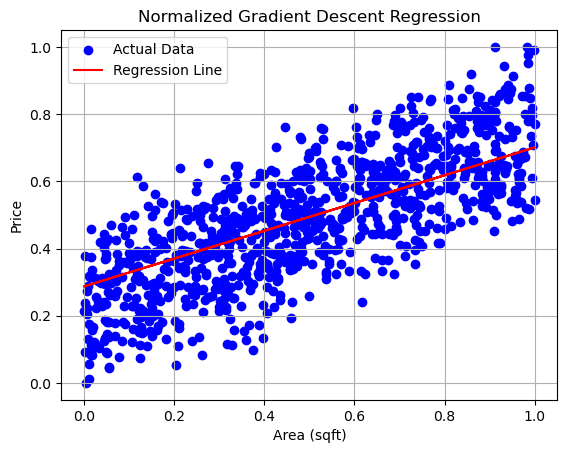

In [13]:


# Min-max normalization
def normalize(data):
    min_val = min(data)
    max_val = max(data)
    return [(x - min_val) / (max_val - min_val) for x in data], min_val, max_val

X, x_min, x_max = normalize(X)
y, y_min, y_max = normalize(y)

# Step 3: Linear Regression with Gradient Descent
class LinearRegressionGD:
    def __init__(self, learning_rate=0.01, max_epochs=10000, tolerance=1e-6):
        self.learning_rate = learning_rate
        self.max_epochs = max_epochs
        self.tolerance = tolerance
        self.m = 0
        self.c = 0

    def fit(self, X, y):
        n = len(X)
        prev_mse = float('inf')

        for epoch in range(self.max_epochs):
            y_pred = [self.m * x + self.c for x in X]
            error = [y[i] - y_pred[i] for i in range(n)]

            # Gradients
            dm = (-2 / n) * sum(X[i] * error[i] for i in range(n))
            dc = (-2 / n) * sum(error)

            # Update
            self.m -= self.learning_rate * dm
            self.c -= self.learning_rate * dc

            # MSE
            mse = sum(e**2 for e in error) / (2*n)

            if epoch % 100 == 0:
                print(f"Epoch {epoch}, MSE: {mse:.6f}, m: {self.m:.4f}, c: {self.c:.4f}")

            if abs(prev_mse - mse) < self.tolerance:
                print(f"Early stopping at epoch {epoch}")
                break

            prev_mse = mse

    def predict(self, X):
        return [self.m * x + self.c for x in X]

# Step 4: Train
model = LinearRegressionGD()
model.fit(X, y)

# Step 5: Make predictions (on normalized data)
y_pred_norm = model.predict(X)

# Step 6: De-normalize predictions
def denormalize(data, data_min, data_max):
    return [y * (data_max - data_min) + data_min for y in data]

y_pred = denormalize(y_pred_norm, y_min, y_max)

# Step 7: Plot
plt.scatter(X, y, color='blue', label='Actual Data')
plt.plot(X, y_pred, color='red', label='Regression Line')
plt.xlabel("Area (sqft)")
plt.ylabel("Price")
plt.title("Normalized Gradient Descent Regression")
plt.legend()
plt.grid(True)
plt.show()

# Step 8: Optional - Output actual slope and intercept in original scale
# (This step is a bit tricky due to normalization but can be derived if needed)


In [14]:
df = pd.read_csv(r"D:\sandeep\Introduction to machine learning\Lab\Student_Performance.csv")  # Replace with your file path
X = df.iloc[:, :-1].values  # All columns except last
y = df.iloc[:, -1].values    # Last column is the target

In [15]:
print(type(X))

<class 'numpy.ndarray'>


In [16]:
print(X.shape)

(10000, 5)


In [17]:
print(X[:,-1])

[1 2 2 ... 5 0 1]


In [18]:
print(y.shape)
    

(10000,)


In [19]:
# Step 2: Min-max normalization
def normalize_features(X):
    min_vals = X.min(axis=0)
    max_vals = X.max(axis=0)
    norm_X = (X - min_vals) / (max_vals - min_vals)
    return norm_X, min_vals, max_vals

def normalize_target(y):
    y_min = np.min(y)
    y_max = np.max(y)
    norm_y = (y - y_min) / (y_max - y_min)
    return norm_y, y_min, y_max

X_norm, X_min, X_max = normalize_features(X)
y_norm, y_min, y_max = normalize_target(y)

In [20]:
min_vals = X.min(axis=0)
print(min_vals)

[ 1 40  0  4  0]


In [21]:
# Step 3: Add bias term (column of 1s)
X_b = np.c_[np.ones((X_norm.shape[0], 1)), X_norm]

In [22]:
print(X_b.shape)

(10000, 6)


In [23]:
# Step 1: Load CSV data




# Step 3: Add bias term (column of 1s)
X_b = np.c_[np.ones((X_norm.shape[0], 1)), X_norm]

# Step 4: Gradient Descent for Multiple Linear Regression
class MultiLinearRegressionGD:
    def __init__(self, learning_rate=0.01, max_epochs=10000, tolerance=1e-6):
        self.learning_rate = learning_rate
        self.max_epochs = max_epochs
        self.tolerance = tolerance
    
    def fit(self, X, y):
        m, n = X.shape
        self.theta = np.zeros(n)
        prev_mse = float('inf')
        
        for epoch in range(self.max_epochs):
            y_pred = X.dot(self.theta)
            error = y_pred - y
            gradient = (1/m) * X.T.dot(error)
            self.theta -= self.learning_rate * gradient
            
            mse = (1/(2*m)) * np.sum(error**2)
            
            if epoch % 100 == 0:
                print(f"Epoch {epoch}, MSE: {mse:.6f}")
            
            if abs(prev_mse - mse) < self.tolerance:
                print(f"Early stopping at epoch {epoch}")
                break
            
            prev_mse = mse

    def predict(self, X):
        return X.dot(self.theta)

# Step 5: Train the model
model = MultiLinearRegressionGD()
model.fit(X_b, y_norm)

# Step 6: Make predictions (normalized)
y_pred_norm = model.predict(X_b)

# Step 7: De-normalize predictions
def denormalize(y_norm, y_min, y_max):
    return y_norm * (y_max - y_min) + y_min

y_pred = denormalize(y_pred_norm, y_min, y_max)

# Step 8: Optional Plot for 1 feature (only when X has 1 column)
if X.shape[1] == 1:
    plt.scatter(X[:, 0], y, color='blue', label='Actual')
    plt.plot(X[:, 0], y_pred, color='red', label='Prediction')
    plt.xlabel("Feature")
    plt.ylabel("Target")
    plt.legend()
    plt.grid(True)
    plt.title("Multiple Linear Regression (1 Feature)")
    plt.show()

# Step 9: Output final weights (denormalized not shown here)
print("Final theta (weights + bias):", model.theta)


Epoch 0, MSE: 0.149035
Epoch 100, MSE: 0.015052
Epoch 200, MSE: 0.011551
Epoch 300, MSE: 0.009673
Epoch 400, MSE: 0.008164
Epoch 500, MSE: 0.006932
Epoch 600, MSE: 0.005918
Epoch 700, MSE: 0.005077
Epoch 800, MSE: 0.004376
Epoch 900, MSE: 0.003788
Epoch 1000, MSE: 0.003293
Epoch 1100, MSE: 0.002874
Epoch 1200, MSE: 0.002519
Epoch 1300, MSE: 0.002217
Epoch 1400, MSE: 0.001960
Epoch 1500, MSE: 0.001740
Epoch 1600, MSE: 0.001551
Epoch 1700, MSE: 0.001389
Epoch 1800, MSE: 0.001249
Epoch 1900, MSE: 0.001128
Early stopping at epoch 1981
Final theta (weights + bias): [ 0.11534573  0.21262401  0.54261867 -0.00097958  0.01696971  0.01257947]


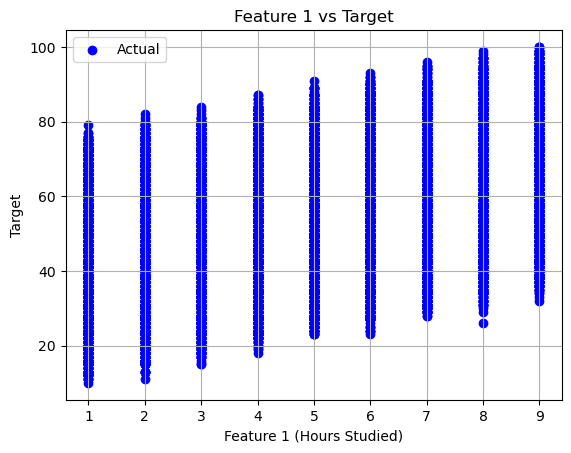

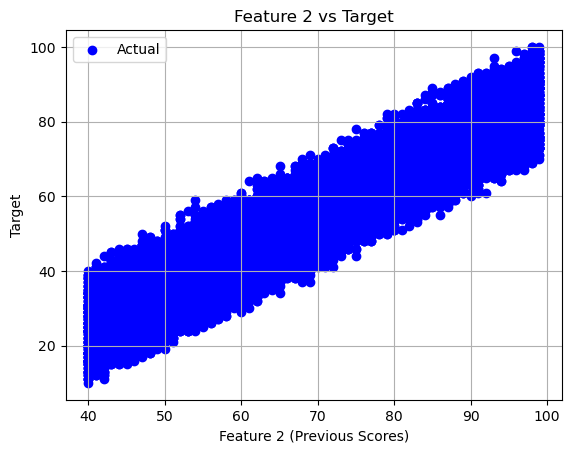

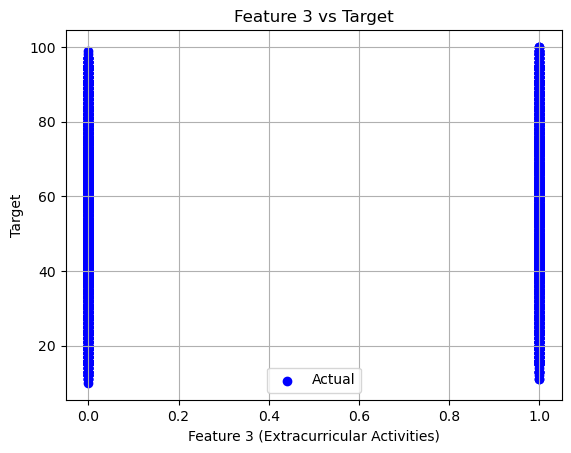

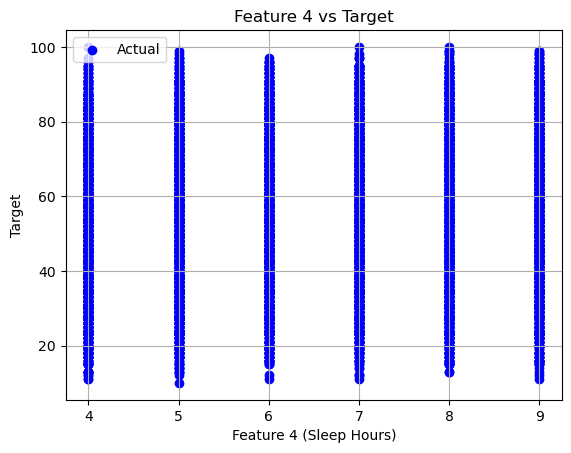

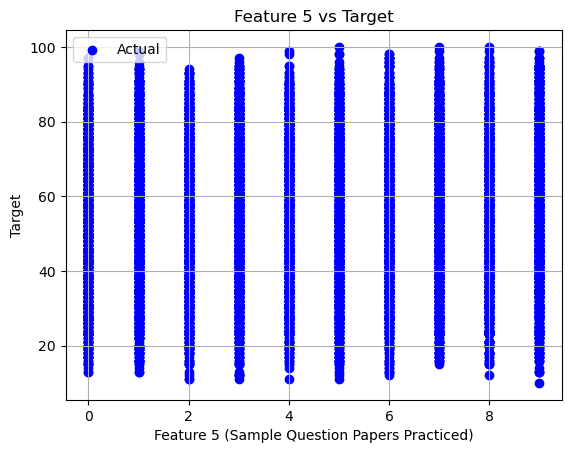

In [24]:
n_features = X.shape[1]
feature_names = df.columns[:-1]  # assuming last column is the target

for i in range(n_features):
    plt.figure()
    plt.scatter(X[:, i], y, color='blue', label='Actual')
    plt.xlabel(f"Feature {i+1} ({feature_names[i]})")
    plt.ylabel("Target")
    plt.title(f"Feature {i+1} vs Target")
    plt.grid(True)
    plt.legend()
    plt.show()

In [25]:
w = np.ones((10,2))
print(w)

[[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]


In [12]:
# y = m * x + c

using_formula_arr = np.empty(1000)
for i in range(len(x)):
    using_formula_arr[i] = m * x[i] + c
#     print(m * x[i] + c, end=", ")

print(using_formula_arr[:10], end=", ")
print("...", end=", ")
print(using_formula_arr[-10:])

[212322.90487091 384074.21961441 420491.68061458 329786.12125342
 345821.39585827 405712.18052698 266417.80715232 360600.89594587
 484342.98491461 276657.19936988], ..., [378857.92546585 212709.29703006 416724.35706284 393251.0333943
 468597.50442913 393444.22947387 208748.77739874 264002.85615762
 210777.33623429 470915.85738405]


In [13]:
np.array_equal(predicted_arr, using_formula_arr)

True

In [14]:
df["predicted_price"] = predicted_arr
display(df)

,area,price,predicted_price
0,1567,177067.50,212322.904871
1,3345,511748.20,384074.219614
2,3722,404096.67,420491.680615
3,2783,357916.31,329786.121253
4,2949,362409.54,345821.395858
...,...,...,...
995,3442,434336.51,393444.229474
996,1530,211400.14,208748.777399
997,2102,172513.03,264002.856158
998,1551,200701.84,210777.336234


Text(0, 0.5, 'Price (in $)')

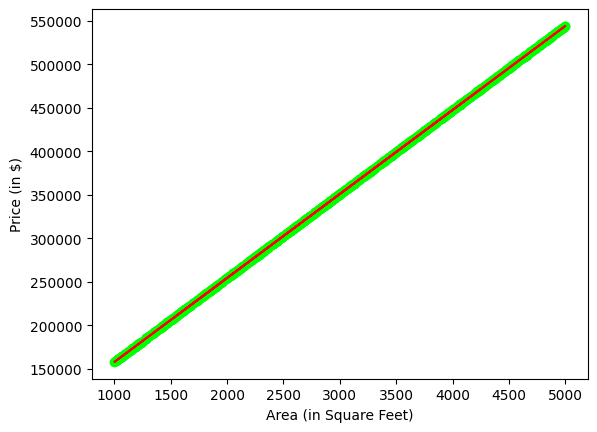

In [15]:
plt.plot(df["area"], df["predicted_price"], color="red")
plt.scatter(df["area"], df["predicted_price"], color="lime")

plt.xlabel("Area (in Square Feet)")
plt.ylabel("Price (in $)")

Why we choose the linear regression line(the red line in this example)?

This is because when we calculate the error which the vertical distance between the actual price and the predicted price (predicted by the linear equation) we square individual errors and we sum them up and we minimise this sum value. We do this for all the other line and we found that the red line was giving me the minimum sum value.

Text(0, 0.5, 'Price (in $)')

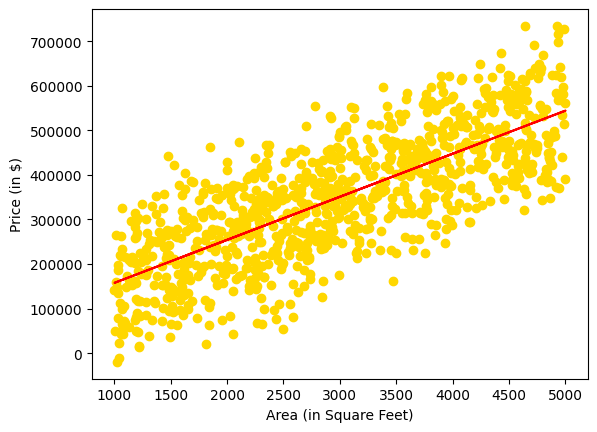

In [16]:
plt.scatter(df["area"], df["price"], color="gold")
plt.plot(df["area"], df["predicted_price"], color="red")

plt.xlabel("Area (in Square Feet)")
plt.ylabel("Price (in $)")

In [17]:
display(df)
print(df.dtypes)

,area,price,predicted_price
0,1567,177067.50,212322.904871
1,3345,511748.20,384074.219614
2,3722,404096.67,420491.680615
3,2783,357916.31,329786.121253
4,2949,362409.54,345821.395858
...,...,...,...
995,3442,434336.51,393444.229474
996,1530,211400.14,208748.777399
997,2102,172513.03,264002.856158
998,1551,200701.84,210777.336234


area                 int64
price              float64
predicted_price    float64
dtype: object
